# Marine Drifter Trajectory Prediction — Baseline Models 

| Tier | Model | Description |
|------|-------|-------------|
| 1 | Persistence, Advection | Physics-only, zero free parameters |
| 2 | Ridge Regression, Random Forest | Data-driven, flattened window |
| 3 | Physics-Constrained RF (PC-RF) | Residual learning on advection prior |

**Primary metric:** Mean geodesic distance error (km, Haversine).  
Secondary: MAE / RMSE on Δlat, Δlon (degrees).  
Note: RMSE on longitude is sensitive to heavy-tailed outliers (especially at high latitudes where
1° lon ≪ 1° lat in km); use mean geodesic error as the headline number.



## 0  Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
from pathlib import Path

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
np.random.seed(42)


def geodesic_km(lat_true, lon_true, lat_pred, lon_pred):
    """Haversine distance in km."""
    R = 6371.0
    phi1, phi2 = np.radians(lat_true), np.radians(lat_pred)
    dphi = np.radians(lat_pred - lat_true)
    dlam = np.radians(lon_pred - lon_true)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


def evaluate(y_true, y_pred, cur_lat, cur_lon, label='model'):
    """
    y_true / y_pred : (N, 2)  [Δlat, Δlon] degrees
    cur_lat / cur_lon: (N,)   position at prediction time (unscaled)
    """
    mae_lat  = mean_absolute_error(y_true[:, 0], y_pred[:, 0])
    mae_lon  = mean_absolute_error(y_true[:, 1], y_pred[:, 1])
    rmse_lat = np.sqrt(mean_squared_error(y_true[:, 0], y_pred[:, 0]))
    rmse_lon = np.sqrt(mean_squared_error(y_true[:, 1], y_pred[:, 1]))

    geo = geodesic_km(
        cur_lat + y_true[:, 0], cur_lon + y_true[:, 1],
        cur_lat + y_pred[:, 0], cur_lon + y_pred[:, 1]
    )
    return dict(
        label=label,
        mae_lat=mae_lat, mae_lon=mae_lon,
        rmse_lat=rmse_lat, rmse_lon=rmse_lon,
        mean_geo=geo.mean(), median_geo=np.median(geo),
        p90_geo=np.percentile(geo, 90),
    ), geo


def print_metrics(r):
    print(f"\n{'='*52}")
    print(f"  {r['label']}")
    print(f"{'='*52}")
    print(f"  MAE  (lat | lon)  : {r['mae_lat']:.5f}° | {r['mae_lon']:.5f}°")
    print(f"  RMSE (lat | lon)  : {r['rmse_lat']:.5f}° | {r['rmse_lon']:.5f}°")
    print(f"  Geo  mean         : {r['mean_geo']:.3f} km")
    print(f"  Geo  median       : {r['median_geo']:.3f} km")
    print(f"  Geo  P90          : {r['p90_geo']:.3f} km")


print('Setup complete.')

Setup complete.


## 1  Load Data

In [2]:
DATA_ROOT = Path('2022-2025_processed_data_extended')
YEARS = [2022, 2023, 2024, 2025]

splits   = {s: [] for s in ['train', 'val', 'test']}
splits_u = {s: [] for s in ['train', 'val', 'test']}
y_all    = {s: [] for s in ['train', 'val', 'test']}
feature_cols = None

for year in YEARS:
    path = (DATA_ROOT / f'{year}_extended'
            / f'drifter_{year}_extended_supervised_windows.npz')
    try:
        d = np.load(path, allow_pickle=True)
        if feature_cols is None:
            feature_cols = list(d['feature_cols'])
        for s in ['train', 'val', 'test']:
            splits[s].append(d[f'X_{s}'])
            splits_u[s].append(d[f'X_{s}_unscaled'])
            y_all[s].append(d[f'y_{s}'])
        print(f'  {year}: train={d["X_train"].shape[0]:>7,}  '
              f'val={d["X_val"].shape[0]:>6,}  test={d["X_test"].shape[0]:>6,}')
    except FileNotFoundError:
        print(f'  {year}: not found, skipping')

X_train   = np.concatenate(splits['train'],   0)
X_val     = np.concatenate(splits['val'],     0)
X_test    = np.concatenate(splits['test'],    0)
X_train_u = np.concatenate(splits_u['train'], 0)
X_val_u   = np.concatenate(splits_u['val'],   0)
X_test_u  = np.concatenate(splits_u['test'],  0)
y_train   = np.concatenate(y_all['train'],    0)
y_val     = np.concatenate(y_all['val'],      0)
y_test    = np.concatenate(y_all['test'],     0)

print(f'\nTrain {X_train.shape[0]:,}  Val {X_val.shape[0]:,}  Test {X_test.shape[0]:,}')
print(f'Window {X_train.shape[1:]}  Target {y_train.shape[1:]}')
print(f'Features: {feature_cols}')

fi = {n: i for i, n in enumerate(feature_cols)}

cur_lat_train = X_train_u[:, -1, fi['latitude']]
cur_lon_train = X_train_u[:, -1, fi['longitude']]
cur_lat_val   = X_val_u[:,  -1, fi['latitude']]
cur_lon_val   = X_val_u[:,  -1, fi['longitude']]
cur_lat_test  = X_test_u[:, -1, fi['latitude']]
cur_lon_test  = X_test_u[:, -1, fi['longitude']]

  2022: train=252,103  val=54,695  test=51,421
  2023: train=291,228  val=62,426  test=56,813
  2024: train=184,041  val=36,085  test=40,805
  2025: train=    383  val=   173  test=   119

Train 727,755  Val 153,379  Test 149,158
Window (8, 21)  Target (2,)
Features: ['latitude', 'longitude', 've', 'vn', 'temp', 'err_lat', 'err_lon', 'err_temp', 'speed', 'direction', 'delta_lat_step', 'delta_lon_step', 'delta_ve_step', 'delta_vn_step', 'accel_east', 'accel_north', 'step_distance_km', 'doy_sin', 'doy_cos', 'hour_sin', 'hour_cos']


## 2  Feature Engineering

The (N, 8, 21) window is flattened to 168 dims (scaled) and augmented with **7 physics-summary
features** derived from the unscaled window:

| Feature | Formula | Rationale |
|---------|---------|----------|
| `adv_dlat` | `vn_last × Δt / 111320` | Advection prediction (northward) |
| `adv_dlon` | `ve_last × Δt / (111320 × cos lat)` | Advection prediction (eastward) |
| `mean_adv_dlat/dlon` | Same using window-mean velocity | Captures velocity trend vs last step |
| `dve_dt`, `dvn_dt` | `v[-1] − v[-2]` | Velocity tendency — is the drifter accelerating? |
| `spd_std` | std(speed over window) | Flow variability proxy |

**Redundancies removed:**
- `delta_lat/lon_last` dropped — equals `adv_dlat/dlon` in different units (same information)
- `net_dlat/dlon` dropped — equals `mean_adv × T` (same information as mean_adv features)

**PC-RF uses a separate feature matrix** (`X_pc`) that **excludes** `adv_dlat`/`adv_dlon`,
so the advection prior enters only through the residual target, not both input and target.

In [3]:
DT_SEC        = 6.0 * 3600          # 21 600 s per step
MS_TO_DEG_LAT = DT_SEC / 111_320.0  # m/s → °lat


def build_features(X_seq, X_u):
    """
    Returns
    -------
    X_full : (N, 175)  168 seq + 7 physics-summary  [for Ridge / RF]
    X_pc   : (N, 173)  168 seq + 5 physics-summary  [for PC-RF: no adv_dlat/dlon]
    adv    : (N, 2)    advection prediction [Δlat, Δlon]
    """
    N = X_seq.shape[0]

    lat = X_u[:, :, fi['latitude']]
    ve  = X_u[:, :, fi['ve']]
    vn  = X_u[:, :, fi['vn']]
    spd = X_u[:, :, fi['speed']]

    last_lat = lat[:, -1]
    cos_lat  = np.cos(np.radians(last_lat))
    cos_lat  = np.where(np.abs(cos_lat) < 1e-6, 1e-6, cos_lat)

    # Advection at last time step  (the physics prediction)
    adv_dlat = vn[:, -1] * MS_TO_DEG_LAT
    adv_dlon = ve[:, -1] * MS_TO_DEG_LAT / cos_lat

    # Advection using window-mean velocity  (trend feature)
    mean_cos      = np.cos(np.radians(lat.mean(1)))
    mean_cos      = np.where(np.abs(mean_cos) < 1e-6, 1e-6, mean_cos)
    mean_adv_dlat = vn.mean(1) * MS_TO_DEG_LAT
    mean_adv_dlon = ve.mean(1) * MS_TO_DEG_LAT / mean_cos

    # Velocity tendency (last two steps)
    dve_dt = ve[:, -1] - ve[:, -2]
    dvn_dt = vn[:, -1] - vn[:, -2]

    # Speed variability over window
    spd_std = spd.std(1)

    flat = X_seq.reshape(N, -1)  # (N, 168) scaled

    # Full feature set: 168 + 7 = 175
    phys_full = np.column_stack([
        adv_dlat, adv_dlon,           # advection prediction
        mean_adv_dlat, mean_adv_dlon, # window-mean advection
        dve_dt, dvn_dt,               # velocity tendency
        spd_std,                      # flow variability
    ])
    X_full = np.concatenate([flat, phys_full], axis=1)  # (N, 175)

    # PC-RF feature set: drop adv_dlat / adv_dlon  →  168 + 5 = 173
    # Advection enters PC-RF only via the residual target, not as an input feature.
    phys_pc = np.column_stack([
        mean_adv_dlat, mean_adv_dlon,
        dve_dt, dvn_dt,
        spd_std,
    ])
    X_pc = np.concatenate([flat, phys_pc], axis=1)      # (N, 173)

    adv = np.column_stack([adv_dlat, adv_dlon])         # (N, 2)
    return X_full, X_pc, adv


print('Building features...')
X_train_full, X_train_pc, adv_train = build_features(X_train, X_train_u)
X_val_full,   X_val_pc,   adv_val   = build_features(X_val,   X_val_u)
X_test_full,  X_test_pc,  adv_test  = build_features(X_test,  X_test_u)

n_seq = X_train.shape[1] * X_train.shape[2]  # 168
print(f'X_full : {X_train_full.shape}  ({n_seq} seq + {X_train_full.shape[1]-n_seq} physics)')
print(f'X_pc   : {X_train_pc.shape}   ({n_seq} seq + {X_train_pc.shape[1]-n_seq} physics, no adv)')

Building features...
X_full : (727755, 175)  (168 seq + 7 physics)
X_pc   : (727755, 173)   (168 seq + 5 physics, no adv)


## 3  Tier 1 — Physics Baselines

**Persistence:** predict zero displacement.  
**Advection:** $\hat{x}_{t+\Delta} = x_t + v_t\Delta t$

In [4]:
res_persist, geo_persist = evaluate(
    y_test, np.zeros_like(y_test), cur_lat_test, cur_lon_test,
    label='Persistence (Tier 1)')
print_metrics(res_persist)

res_adv, geo_adv = evaluate(
    y_test, adv_test, cur_lat_test, cur_lon_test,
    label='Advection (Tier 1)')
print_metrics(res_adv)


  Persistence (Tier 1)
  MAE  (lat | lon)  : 0.09797° | 0.16401°
  RMSE (lat | lon)  : 0.14693° | 0.79057°
  Geo  mean         : 19.108 km
  Geo  median       : 14.208 km
  Geo  P90          : 39.715 km

  Advection (Tier 1)
  MAE  (lat | lon)  : 0.07681° | 0.12680°
  RMSE (lat | lon)  : 0.11522° | 0.67563°
  Geo  mean         : 14.821 km
  Geo  median       : 11.063 km
  Geo  P90          : 30.677 km


## 4  Tier 2 — Classical ML

### Ridge Regression
Alpha chosen by validation geodesic error sweep.

### Random Forest
Full training set (727 k samples). `min_samples_leaf=10` to reduce sensitivity to
longitude outliers at high latitudes (the heavy tail observed in the lon error distribution).

In [5]:
print('Ridge alpha sweep on validation set...')
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
print(f'{"alpha":>10}  {"val mean geo (km)":>18}')
print('-' * 32)
best_alpha, best_val = None, np.inf
for a in alphas:
    pred = Ridge(alpha=a).fit(X_train_full, y_train).predict(X_val_full)
    r, _ = evaluate(y_val, pred, cur_lat_val, cur_lon_val)
    print(f'{a:>10.3f}  {r["mean_geo"]:>18.3f}')
    if r['mean_geo'] < best_val:
        best_val, best_alpha = r['mean_geo'], a
print(f'\nBest alpha = {best_alpha}  (val = {best_val:.3f} km)')

ridge = Ridge(alpha=best_alpha).fit(X_train_full, y_train)
y_ridge = ridge.predict(X_test_full)
res_ridge, geo_ridge = evaluate(
    y_test, y_ridge, cur_lat_test, cur_lon_test, label='Ridge (Tier 2)')
print_metrics(res_ridge)

Ridge alpha sweep on validation set...
     alpha   val mean geo (km)
--------------------------------
     0.010               7.603
     0.100               7.605
     1.000               7.600
    10.000               7.583
   100.000               7.565
  1000.000               7.637

Best alpha = 100.0  (val = 7.565 km)

  Ridge (Tier 2)
  MAE  (lat | lon)  : 0.04558° | 0.06513°
  RMSE (lat | lon)  : 0.07133° | 0.56155°
  Geo  mean         : 7.800 km
  Geo  median       : 5.992 km
  Geo  P90          : 15.272 km


In [6]:
print(f'Training RF on {X_train_full.shape[0]:,} samples...')
rf = RandomForestRegressor(
    n_estimators=200, max_depth=14,
    min_samples_leaf=10,   # increased from 5 to reduce outlier sensitivity
    n_jobs=-1, random_state=42
)
rf.fit(X_train_full, y_train)
y_rf = rf.predict(X_test_full)
res_rf, geo_rf = evaluate(
    y_test, y_rf, cur_lat_test, cur_lon_test, label='Random Forest (Tier 2)')
print_metrics(res_rf)

Training RF on 727,755 samples...

  Random Forest (Tier 2)
  MAE  (lat | lon)  : 0.04281° | 0.06178°
  RMSE (lat | lon)  : 0.06550° | 0.70355°
  Geo  mean         : 7.251 km
  Geo  median       : 5.486 km
  Geo  P90          : 14.426 km


## 5  Tier 3 — Physics-Constrained RF (PC-RF)

$$\hat{y} = \underbrace{v_t\Delta t}_{\text{advection}} + f_\theta(X_t)$$

$f_\theta$ is a RF trained on residuals $y - v_t\Delta t$.
The input matrix **excludes** `adv_dlat`/`adv_dlon` so that the advection prior enters
exclusively through the target, making the physics contribution cleanly separable.

In [7]:
y_resid_train = y_train - adv_train   # what remains after physics

print(f'Training PC-RF on residuals (N={X_train_pc.shape[0]:,})...')
rf_pc = RandomForestRegressor(
    n_estimators=200, max_depth=14,
    min_samples_leaf=10,
    n_jobs=-1, random_state=42
)
rf_pc.fit(X_train_pc, y_resid_train)

y_pc_rf = adv_test + rf_pc.predict(X_test_pc)
res_pc_rf, geo_pc_rf = evaluate(
    y_test, y_pc_rf, cur_lat_test, cur_lon_test, label='PC-RF (Tier 3)')
print_metrics(res_pc_rf)

Training PC-RF on residuals (N=727,755)...

  PC-RF (Tier 3)
  MAE  (lat | lon)  : 0.04322° | 0.06260°
  RMSE (lat | lon)  : 0.06547° | 0.64625°
  Geo  mean         : 7.365 km
  Geo  median       : 5.625 km
  Geo  P90          : 14.561 km


## 6  Summary Table

In [8]:
all_res = [res_persist, res_adv, res_ridge, res_rf, res_pc_rf]

df_sum = pd.DataFrame([{
    'Model':           r['label'],
    'MAE lat (°)':     f"{r['mae_lat']:.5f}",
    'MAE lon (°)':     f"{r['mae_lon']:.5f}",
    'RMSE lat (°)':    f"{r['rmse_lat']:.5f}",
    'RMSE lon (°)':    f"{r['rmse_lon']:.5f}",
    'Mean geo (km)':   f"{r['mean_geo']:.3f}",
    'Median geo (km)': f"{r['median_geo']:.3f}",
    'P90 geo (km)':    f"{r['p90_geo']:.3f}",
} for r in all_res])

pd.set_option('display.max_colwidth', 35)
pd.set_option('display.width', 220)
print(df_sum.to_string(index=False))

best = min(all_res, key=lambda r: r['mean_geo'])
print(f"\nTarget for LSTM/Transformer: < {best['mean_geo']:.3f} km  [{best['label']}]")

                 Model MAE lat (°) MAE lon (°) RMSE lat (°) RMSE lon (°) Mean geo (km) Median geo (km) P90 geo (km)
  Persistence (Tier 1)     0.09797     0.16401      0.14693      0.79057        19.108          14.208       39.715
    Advection (Tier 1)     0.07681     0.12680      0.11522      0.67563        14.821          11.063       30.677
        Ridge (Tier 2)     0.04558     0.06513      0.07133      0.56155         7.800           5.992       15.272
Random Forest (Tier 2)     0.04281     0.06178      0.06550      0.70355         7.251           5.486       14.426
        PC-RF (Tier 3)     0.04322     0.06260      0.06547      0.64625         7.365           5.625       14.561

Target for LSTM/Transformer: < 7.251 km  [Random Forest (Tier 2)]


## 7  Visualisations

### 7a  Error CDF and bar chart

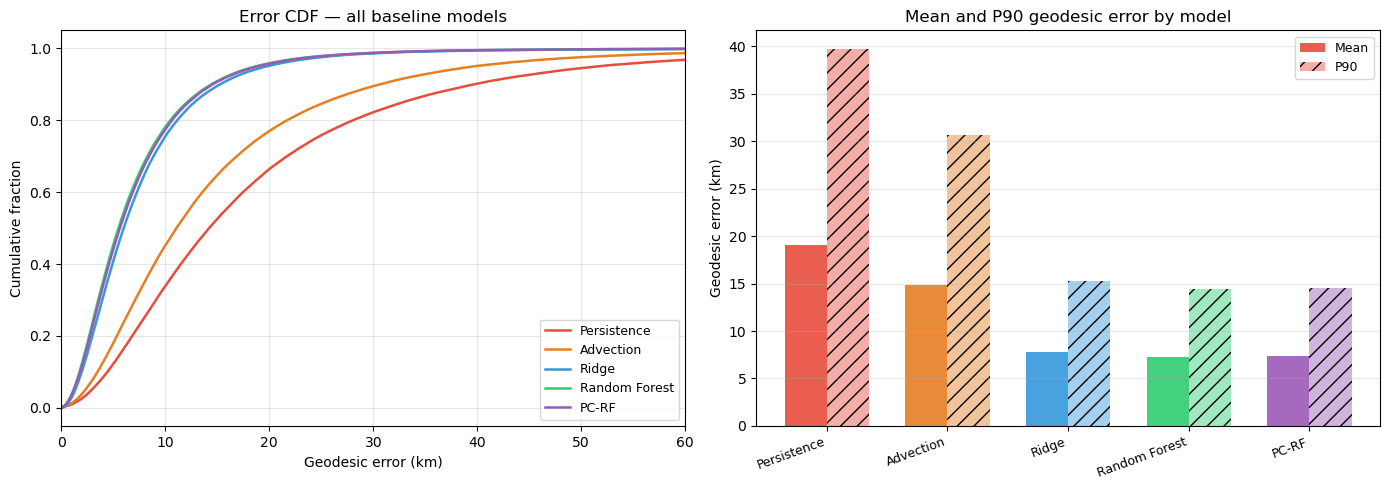

In [9]:
palette = {
    'Persistence':  '#e74c3c',
    'Advection':    '#e67e22',
    'Ridge':        '#3498db',
    'Random Forest':'#2ecc71',
    'PC-RF':        '#9b59b6',
}
model_geo = [
    ('Persistence',   geo_persist, palette['Persistence']),
    ('Advection',     geo_adv,     palette['Advection']),
    ('Ridge',         geo_ridge,   palette['Ridge']),
    ('Random Forest', geo_rf,      palette['Random Forest']),
    ('PC-RF',         geo_pc_rf,   palette['PC-RF']),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, geo, col in model_geo:
    s = np.sort(geo)
    ax.plot(s, np.arange(1, len(s)+1)/len(s), color=col, label=name, lw=1.8)
ax.set_xlim(0, 60)
ax.set_xlabel('Geodesic error (km)')
ax.set_ylabel('Cumulative fraction')
ax.set_title('Error CDF — all baseline models')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax2 = axes[1]
x = np.arange(len(model_geo))
w = 0.35
names  = [n for n,_,_ in model_geo]
means  = [np.mean(g)            for _,g,_ in model_geo]
p90s   = [np.percentile(g, 90)  for _,g,_ in model_geo]
colors = [c                     for _,_,c in model_geo]
ax2.bar(x-w/2, means, w, color=colors, alpha=0.9, label='Mean')
ax2.bar(x+w/2, p90s,  w, color=colors, alpha=0.45, hatch='//', label='P90')
ax2.set_xticks(x); ax2.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Geodesic error (km)')
ax2.set_title('Mean and P90 geodesic error by model')
ax2.legend(fontsize=9); ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('baseline_error_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 7b  Trajectory visualisation — qualitative comparison

We pick **12 representative test samples** (4 low-error, 4 medium-error, 4 high-error
based on RF geodesic error) and show the 8-step history, true future position, and all
model predictions.

Fixed sample indices (save these for LSTM team):
[19320, 125417, 680, 54370, 109997, 62284, 142222, 35486, 48055, 131006, 144394, 136381]


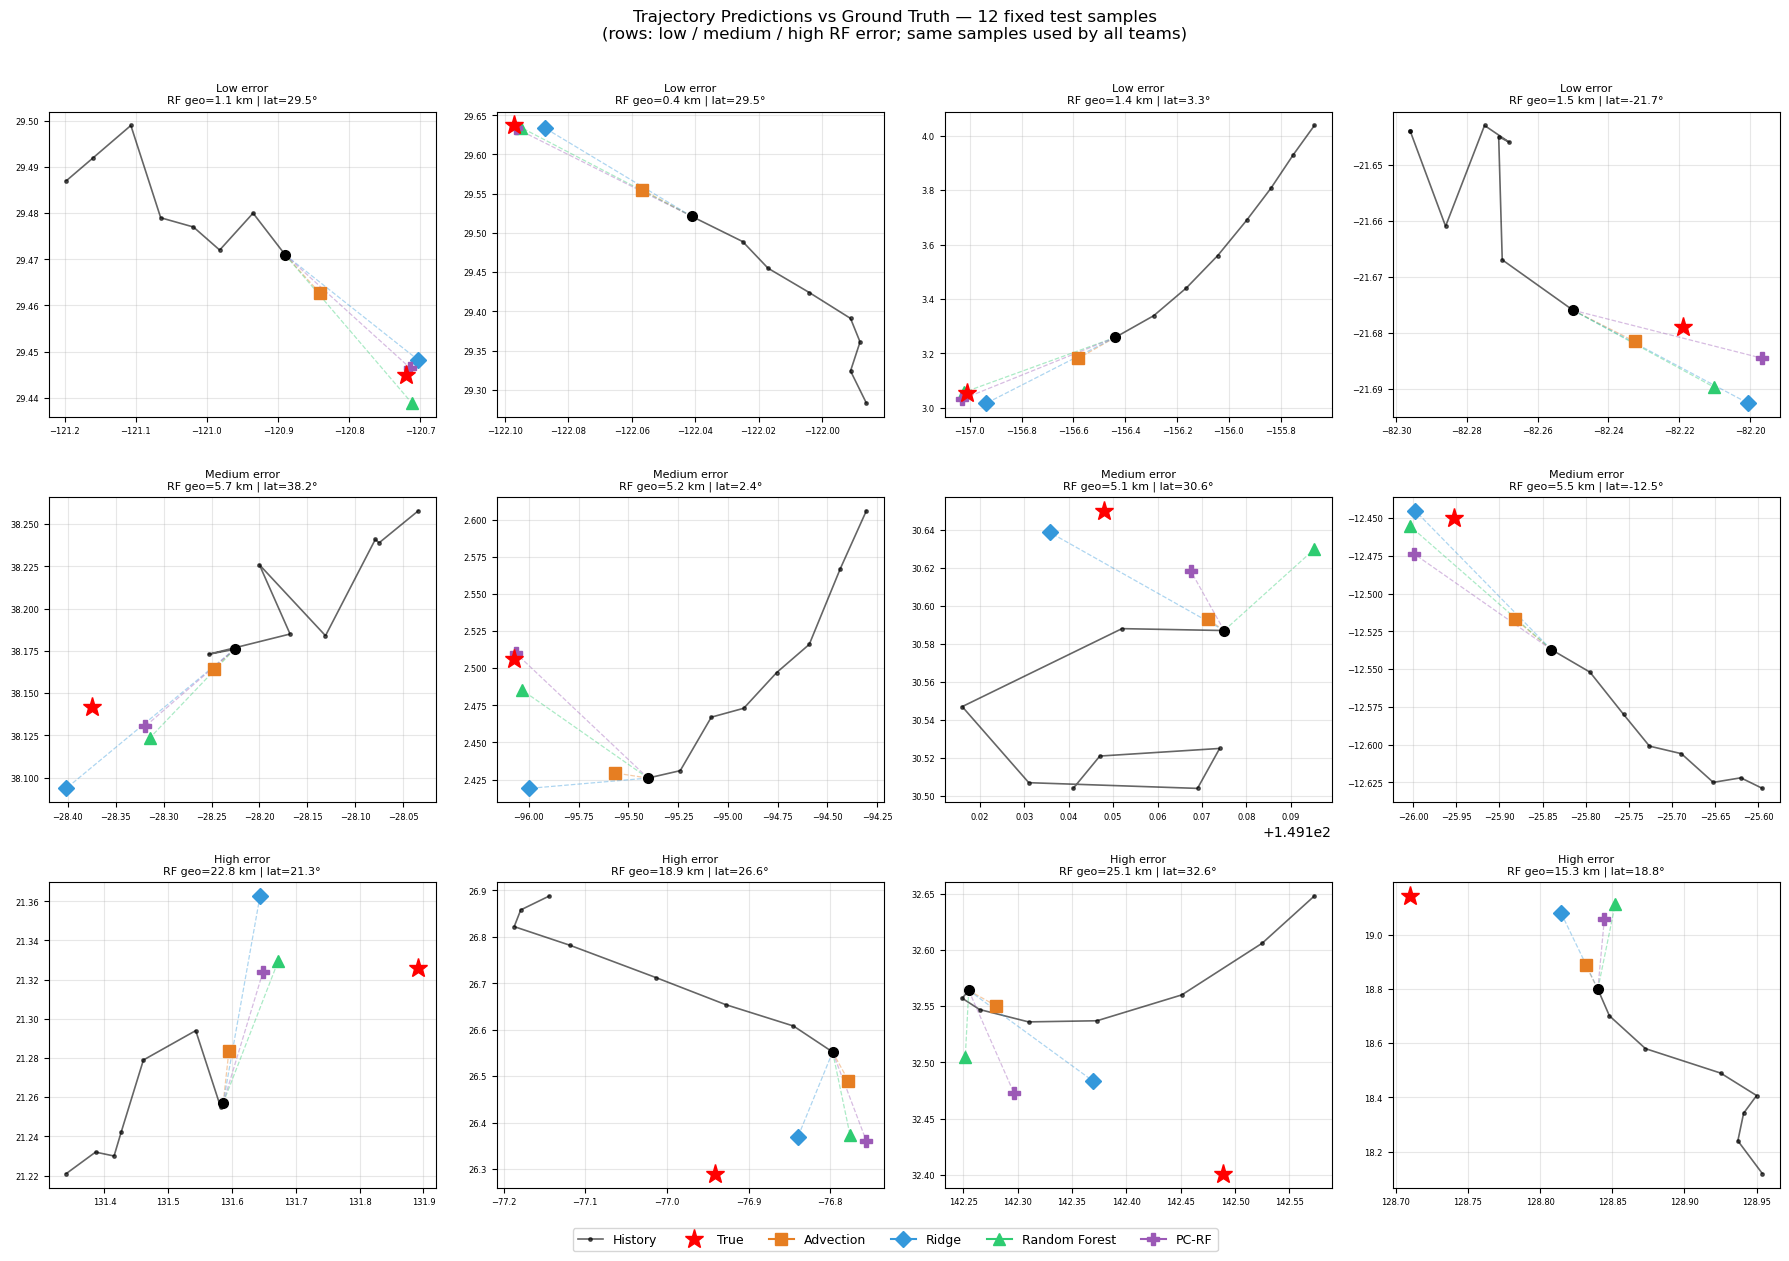

Saved: trajectory_comparison.png


In [15]:
# ── Select 12 representative samples and FIX the indices ─────────────────────
# Indices are fixed with a fixed seed so the LSTM/Transformer team can
# visualise their predictions on exactly the same samples for direct comparison.
n_each = 4
n_test  = len(geo_rf)
sorted_idx = np.argsort(geo_rf)

low_idx  = sorted_idx[:int(n_test * 0.1)]
med_idx  = sorted_idx[int(n_test * 0.45):int(n_test * 0.55)]
high_idx = sorted_idx[int(n_test * 0.9):]

rng = np.random.default_rng(42)          # fixed seed — DO NOT CHANGE
sample_idx = np.concatenate([
    rng.choice(low_idx,  n_each, replace=False),
    rng.choice(med_idx,  n_each, replace=False),
    rng.choice(high_idx, n_each, replace=False),
])
row_labels = (['Low error'] * n_each +
              ['Medium error'] * n_each +
              ['High error'] * n_each)

print(f"Fixed sample indices (save these for LSTM team):")
print(sample_idx.tolist())

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

pred_styles = [
    ('Advection',     adv_test, palette['Advection'],     's', '--'),
    ('Ridge',         y_ridge,  palette['Ridge'],         'D', '--'),
    ('Random Forest', y_rf,     palette['Random Forest'], '^', '--'),
    ('PC-RF',         y_pc_rf,  palette['PC-RF'],         'P', '--'),
]

for plot_i, (si, row_lbl) in enumerate(zip(sample_idx, row_labels)):
    ax = axes[plot_i // 4][plot_i % 4]

    hlat = X_test_u[si, :, fi['latitude']]
    hlon = X_test_u[si, :, fi['longitude']]
    ax.plot(hlon, hlat, 'k.-', lw=1.2, ms=5, alpha=0.6, label='History')

    clat = hlat[-1]; clon = hlon[-1]
    ax.plot(clon, clat, 'ko', ms=7, zorder=8)

    tlat = clat + y_test[si, 0]
    tlon = clon + y_test[si, 1]
    ax.plot(tlon, tlat, 'r*', ms=14, zorder=10, label='True')

    for pname, ypred, pcol, pmark, pls in pred_styles:
        plat = clat + ypred[si, 0]
        plon = clon + ypred[si, 1]
        ax.plot(plon, plat, marker=pmark, color=pcol, ms=8, zorder=9, label=pname)
        ax.plot([clon, plon], [clat, plat], ls=pls, color=pcol, alpha=0.4, lw=0.9)

    ax.set_title(
        f"{row_lbl}\nRF geo={geo_rf[si]:.1f} km | lat={clat:.1f}°",
        fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

handles, labels_leg = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    'Trajectory Predictions vs Ground Truth — 12 fixed test samples\n'
    '(rows: low / medium / high RF error; same samples used by all teams)',
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: trajectory_comparison.png')


### 7c  Error vs dynamic complexity

Addresses reviewer point #3: Error increases systematically with local speed, justifying how rising physical complexity escalates prediction difficulty and causes traditional advection to break down completely.

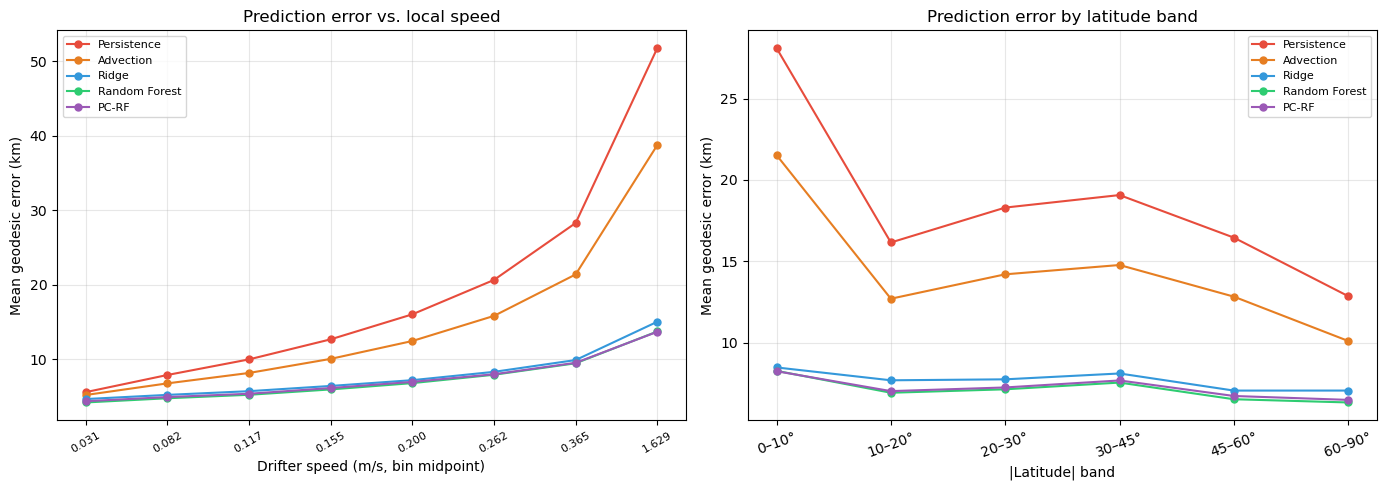

In [12]:
last_spd = X_test_u[:, -1, fi['speed']]
spd_bins = pd.qcut(last_spd, q=8, duplicates='drop')
bin_mids = [f"{iv.mid:.3f}" for iv in spd_bins.categories]

def geo_by_bin(geo, bins):
    return (pd.DataFrame({'g': geo, 'b': bins})
            .groupby('b', observed=False)['g'].mean().values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, geo, col in model_geo:
    ax.plot(range(len(bin_mids)), geo_by_bin(geo, spd_bins),
            'o-', color=col, label=name, ms=5)
ax.set_xticks(range(len(bin_mids)))
ax.set_xticklabels(bin_mids, rotation=30, fontsize=8)
ax.set_xlabel('Drifter speed (m/s, bin midpoint)')
ax.set_ylabel('Mean geodesic error (km)')
ax.set_title('Prediction error vs. local speed')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
lat_bins = pd.cut(np.abs(cur_lat_test),
                  bins=[-1, 10, 20, 30, 45, 60, 90],
                  labels=['0–10°','10–20°','20–30°','30–45°','45–60°','60–90°'])
for name, geo, col in model_geo:
    means = (pd.DataFrame({'g': geo, 'lb': lat_bins})
             .groupby('lb', observed=False)['g'].mean().values)
    ax2.plot(range(6), means, 'o-', color=col, label=name, ms=5)
ax2.set_xticks(range(6))
ax2.set_xticklabels(['0–10°','10–20°','20–30°','30–45°','45–60°','60–90°'], rotation=20)
ax2.set_xlabel('|Latitude| band')
ax2.set_ylabel('Mean geodesic error (km)')
ax2.set_title('Prediction error by latitude band')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_vs_complexity.png', dpi=150, bbox_inches='tight')
plt.show()

## 8  Complexity Analysis

Spearman correlation between local speed / acceleration and advection error
demonstrates that dynamic complexity — not data dimensionality — is the core challenge.

In [14]:
from scipy.stats import spearmanr

last_accel = np.sqrt(
    X_test_u[:, -1, fi['accel_east']]**2 +
    X_test_u[:, -1, fi['accel_north']]**2
)

r_spd,   p_spd   = spearmanr(last_spd,   geo_adv)
r_accel, p_accel = spearmanr(last_accel, geo_adv)

print('Spearman correlation with advection error:')
print(f'  Local speed        : r = {r_spd:.4f}   p = {p_spd:.2e}')
print(f'  Local acceleration : r = {r_accel:.4f}   p = {p_accel:.2e}')
print()
print('RF vs Ridge improvement by speed quintile:')
df_nl = pd.DataFrame({
    'spd': last_spd, 'rf': geo_rf, 'ridge': geo_ridge,
    'bin': pd.qcut(last_spd, q=5, duplicates='drop')
})
s = df_nl.groupby('bin').agg(
    n=('spd','count'), mean_spd=('spd','mean'),
    ridge=('ridge','mean'), rf=('rf','mean')
)
s['rf_gain_km'] = s['ridge'] - s['rf']
print(s.to_string())

Spearman correlation with advection error:
  Local speed        : r = 0.7869   p = 0.00e+00
  Local acceleration : r = 0.2660   p = 0.00e+00

RF vs Ridge improvement by speed quintile:
                      n  mean_spd      ridge         rf  rf_gain_km
bin                                                                
(-0.001, 0.0853]  29832  0.052652   4.826159   4.374190    0.451969
(0.0853, 0.142]   29831  0.113264   5.693899   5.197326    0.496572
(0.142, 0.214]    29832  0.176182   6.750706   6.342582    0.408124
(0.214, 0.341]    29831  0.269110   8.473755   8.082622    0.391133
(0.341, 2.826]    29832  0.552311  13.256832  12.260369    0.996463


## 9  Save Outputs

In [18]:
np.savez('baseline_predictions.npz',
    # Ground truth
    y_test=y_test,                   # (N, 2) true [Δlat, Δlon]
    cur_lat_test=cur_lat_test,       # (N,)   lat at prediction time
    cur_lon_test=cur_lon_test,       # (N,)   lon at prediction time
    # Baseline predictions (N, 2) each — predicted [Δlat, Δlon]
    y_persist=np.zeros_like(y_test),
    y_adv=adv_test,
    y_ridge=y_ridge,
    y_rf=y_rf,
    y_pc_rf=y_pc_rf,
    # Per-sample geodesic errors (N,) in km
    geo_persist=geo_persist,
    geo_adv=geo_adv,
    geo_ridge=geo_ridge,
    geo_rf=geo_rf,
    geo_pc_rf=geo_pc_rf,
    # Fixed visualisation indices — LSTM team uses these same 12 samples
    # so all models can be compared on identical trajectories
    viz_sample_idx=sample_idx,       # (12,) fixed indices into test set
    viz_row_labels=np.array(row_labels),
)
df_sum.to_csv('baseline_metrics.csv', index=False)

# ─────────────────────────────────────────────────
print('Saved: baseline_predictions.npz, baseline_metrics.csv')
print()
print('Contents of baseline_predictions.npz:')
print('  y_test, cur_lat/lon_test  — ground truth & current positions')
print('  y_persist/adv/ridge/rf/pc_rf  — each model\'s predicted [Δlat, Δlon]')
print('  geo_*  — per-sample geodesic error (km) for each model')
print('  viz_sample_idx (12,)  — FIXED indices for trajectory comparison plots')
print()
print('LSTM/Transformer team instructions:')
print('  1. Load baseline_predictions.npz')
print('  2. Run your model, get y_lstm of shape (N, 2)')
print('  3. Use viz_sample_idx to select the same 12 samples')
print('  4. Plot all predictions (baseline + LSTM) on the same trajectory figures')
print()
print('=' * 55)
print('FINAL BASELINE — target for LSTM/Transformer to beat')
print('=' * 55)
for r in all_res:
    print(f"  {r['label']:<38} {r['mean_geo']:>6.3f} km")
best = min(all_res, key=lambda r: r['mean_geo'])
print(f"\n  Beat this: < {best['mean_geo']:.3f} km  [{best['label']}]")

Saved: baseline_predictions.npz, baseline_metrics.csv

Contents of baseline_predictions.npz:
  y_test, cur_lat/lon_test  — ground truth & current positions
  y_persist/adv/ridge/rf/pc_rf  — each model's predicted [Δlat, Δlon]
  geo_*  — per-sample geodesic error (km) for each model
  viz_sample_idx (12,)  — FIXED indices for trajectory comparison plots

LSTM/Transformer team instructions:
  1. Load baseline_predictions.npz
  2. Run your model, get y_lstm of shape (N, 2)
  3. Use viz_sample_idx to select the same 12 samples
  4. Plot all predictions (baseline + LSTM) on the same trajectory figures

FINAL BASELINE — target for LSTM/Transformer to beat
  Persistence (Tier 1)                   19.108 km
  Advection (Tier 1)                     14.821 km
  Ridge (Tier 2)                          7.800 km
  Random Forest (Tier 2)                  7.251 km
  PC-RF (Tier 3)                          7.365 km

  Beat this: < 7.251 km  [Random Forest (Tier 2)]


In [17]:
import joblib
joblib.dump(rf, "rf_model.pkl")
joblib.dump(ridge, "ridge_model.pkl")
joblib.dump(rf_pc, "rf_pc_model.pkl")

['rf_pc_model.pkl']